# ***`Libraries`***

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models


# ***`Read Data`***

In [56]:
df = pd.read_csv('data_demvk.csv')
X = df.values.astype(np.float32)
print("Data shape:", X.shape)

Data shape: (3765, 13)


# ***`Setting`***

In [57]:
import warnings
warnings.filterwarnings("ignore")

In [58]:
# Thiết lập seed để có kết quả tái lập
tf.random.set_seed(42)
np.random.seed(42)

In [59]:
input_dim = X.shape[1]


# ***`3.3.1 Representation Learning (autoencoders)`***

In [60]:
from tensorflow.keras.layers import Input, Dense, Concatenate
from tensorflow.keras.models import Model

def build_view1_models(input_dim=13, latent_dim=10):
    """
    View 1: MLP Autoencoder fully connected theo sơ đồ.
    - Trả về:
        + autoencoder: dùng để huấn luyện với MSE (input → reconstruction)
        + embedding_model: xuất [latent + reconstruction] (23-d embedding)
    """
    inp = Input(shape=(input_dim,), name='view1_input')

    # --- Encoder ---
    e1 = Dense(500, activation='relu')(inp)
    e2 = Dense(500, activation='relu')(e1)
    e3 = Dense(2000, activation='relu')(e2)
    bottleneck = Dense(latent_dim, activation='linear', name='bottleneck_view1')(e3)

    # --- Decoder ---
    d1 = Dense(2000, activation='relu')(bottleneck)
    d2 = Dense(500, activation='relu')(d1)
    d3 = Dense(500, activation='relu')(d2)
    reconstruction = Dense(input_dim, activation='linear', name='reconstruction_view1')(d3)

    # --- Autoencoder (13 → 13) ---
    autoencoder = Model(inputs=inp, outputs=reconstruction, name='View1_Autoencoder')

    # --- Embedding model (13 → 23) ---
    embedding_output = Concatenate(name='view1_embedding')([bottleneck, reconstruction])
    embedding_model = Model(inputs=inp, outputs=embedding_output, name='View1_EmbeddingModel')

    return autoencoder, embedding_model



def build_view2_models(input_dim=13):
    """
    View 2: Autoencoder kiểu U-Net với skip connection.
    - Trả về:
        + autoencoder: dùng để train (output = reconstruction)
        + embedding_model: dùng để lấy output 23-d embedding
    """
    inp = Input(shape=(input_dim,), name='view2_input')

    # --- Encoder ---
    x1 = Dense(64, activation='relu')(inp)          # skip_1
    x2 = Dense(64, activation='relu')(x1)
    x3 = Dense(128, activation='relu')(x2)          # skip_2
    x4 = Dense(128, activation='relu')(x3)
    x5 = Dense(256, activation='relu')(x4)
    x6 = Dense(256, activation='relu')(x5)          # skip_3
    x7 = Dense(512, activation='relu')(x6)
    x8 = Dense(512, activation='relu')(x7)          # skip_4
    x9 = Dense(1024, activation='relu')(x8)
    x10 = Dense(512, activation='relu')(x9)
    x11 = Dense(256, activation='relu')(x10)
    x12 = Dense(128, activation='relu')(x11)

    # --- Decoder ---
    d1 = Dense(256, activation='relu')(x12)
    d1_concat = Concatenate()([d1, x8])
    d2 = Dense(512, activation='relu')(d1_concat)
    d3 = Dense(256, activation='relu')(d2)

    d4 = Dense(128, activation='relu')(d3)
    d4_concat = Concatenate()([d4, x6])
    d5 = Dense(256, activation='relu')(d4_concat)
    d6 = Dense(128, activation='relu')(d5)

    s1 = Dense(64, activation='relu')(d6)
    s1_concat = Concatenate()([s1, x3])
    s2 = Dense(128, activation='relu')(s1_concat)
    s3 = Dense(64, activation='relu')(s2)

    s4 = Dense(32, activation='relu')(s3)
    s4_concat = Concatenate()([s4, x1])
    s5 = Dense(64, activation='relu')(s4_concat)

    # --- Output ---
    embedding = Dense(23, activation=None, name='view2_embedding')(s5)
    reconstruction = Dense(input_dim, activation='linear', name='reconstruction_view2')(embedding)

    # --- Models ---
    autoencoder = Model(inputs=inp, outputs=reconstruction, name='View2_Autoencoder')
    embedding_model = Model(inputs=inp, outputs=embedding, name='View2_EmbeddingModel')

    return autoencoder, embedding_model


In [61]:
# Build View 1
auto_v1, embed_v1 = build_view1_models(input_dim=X.shape[1])
auto_v1.compile(optimizer='adam', loss='mse')

# Build View 2
auto_v2, embed_v2 = build_view2_models(input_dim=X.shape[1])
auto_v2.compile(optimizer='adam', loss='mse')

# Train
auto_v1.fit(X, X, epochs=100, batch_size=64)
auto_v2.fit(X, X, epochs=100, batch_size=64)

# Predict embedding
h1 = embed_v1.predict(X)           # (n_samples, 23)
h2 = embed_v2.predict(X)           # (n_samples, 23)


Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 4862009.5000
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8383.9131
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70.3599
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3221
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0440
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0394
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0397
Epoch 8/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0399
Epoch 9/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0479
Epoch 10/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0555
Epoch 11/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1226
Epoch 12/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0851
Epoch 13/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3211
Epoch 14/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8959
Epoch 15/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 

In [62]:
print(h1.shape, h2.shape)
print(x_hat1.shape, x_hat2.shape)
print(h_fused.shape)

(3765, 23) (3765, 23)
(3765, 13) (3765, 13)
(3765, 23)


In [63]:
from sklearn.metrics import mean_squared_error

# Fused embedding: trung bình cộng h1 và h2
h_fused = 0.5 * (h1 + h2)  # shape: (n_samples, 23)

# Dự đoán tái thiết từ cả hai autoencoder
x_hat1 = auto_v1.predict(X)  # (n_samples, input_dim)
x_hat2 = auto_v2.predict(X)  # (n_samples, input_dim)

# Tính L1: tổng MSE của cả hai reconstruction
L1 = np.mean(np.square(X - x_hat1)) + np.mean(np.square(X - x_hat2))
print("Reconstruction Loss L1 =", L1)


118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Reconstruction Loss L1 = 918.572


# ***`3.3.2. clustering in the fused embedding space (K-means objective)`***

In [64]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

def clustering_fused_embedding(h_fused, n_clusters=4, random_state=42,
                               calc_silhouette=True, use_gridsearch=True):
    """
    Bước 3.3.2: Clustering trong không gian fused embedding.
    - Áp dụng KMeans với GridSearch để chọn 'init' tốt nhất theo Silhouette Score.
    - Tính loss L2 theo phương trình (6) của bài báo:
          L2 = ∑_{j=1}^{k} ∑_{h_i ∈ C_j} || h_i - μ_j ||²
    """
    init_methods = ['random', 'k-means++'] if use_gridsearch else ['k-means++']

    best_score = -1
    best_result = {}
    fallback_result = {}

    for init_method in init_methods:
        kmeans = KMeans(n_clusters=n_clusters, init=init_method, random_state=random_state)
        labels = kmeans.fit_predict(h_fused)
        centroids = kmeans.cluster_centers_

        # Tính L2
        L2 = np.sum([
            np.sum((h_fused[i] - centroids[labels[i]]) ** 2)
            for i in range(len(h_fused))
        ])

        # Tính silhouette
        silhouette = None
        if calc_silhouette and len(set(labels)) > 1:
            silhouette = silhouette_score(h_fused, labels)

        sil_text = f" | Silhouette = {silhouette:.4f}" if silhouette is not None else ""
        print(f"[{init_method.upper()}] L₂ = {L2:.4f}{sil_text}")

        # Ghi lại fallback kết quả cuối cùng
        fallback_result = {
            'labels': labels,
            'centroids': centroids,
            'L2': L2,
            'silhouette': silhouette
        }

        # Cập nhật kết quả tốt nhất nếu cần
        if silhouette is not None and silhouette > best_score:
            best_score = silhouette
            best_result = {
                'labels': labels,
                'centroids': centroids,
                'L2': L2,
                'silhouette': silhouette,
                'init': init_method
            }

    # Trường hợp fallback nếu không tìm thấy silhouette tốt hơn
    if not use_gridsearch or not best_result:
        return (fallback_result['labels'],
                fallback_result['centroids'],
                fallback_result['L2'],
                fallback_result['silhouette'])

    print(f"\n✅ Best Init = '{best_result['init']}' with Silhouette = {best_result['silhouette']:.4f}")
    return best_result['labels'], best_result['centroids'], best_result['L2'], best_result['silhouette']


In [65]:
labels, centroids, L2, silhouette = clustering_fused_embedding(h_fused, n_clusters=5)


[RANDOM] L₂ = 15525257216.0000 | Silhouette = 0.6195
[K-MEANS++] L₂ = 15525342208.0000 | Silhouette = 0.6189

✅ Best Init = 'random' with Silhouette = 0.6195


# ***`3.3.3. orthonormal transformation using eigenvectors`***

In [66]:
def orthonormal_transformation(h_fused, labels, centroids):
    """
    Bước 3.3.3: Trực chuẩn hoá embedding không gian mới (y_i = V * h_i).

    Args:
        h_fused (ndarray): Fused embedding, shape (n_samples, d)
        labels (ndarray): Nhãn cụm từ KMeans
        centroids (ndarray): Tâm cụm KMeans (μ_j)

    Returns:
        y (ndarray): Embedding sau biến đổi (y_i = V * h_i)
        V (ndarray): Ma trận trực chuẩn (eigenvectors of S_w)
        L3 (float): Truy vết (trace) dùng làm loss (Eq. 9)
    """
    n_clusters = centroids.shape[0]
    d = h_fused.shape[1]

    # Tính ma trận S_w (within-class scatter matrix)
    S_w = np.zeros((d, d))
    for j in range(n_clusters):
        cluster_points = h_fused[labels == j]
        mu_j = centroids[j]
        for h_i in cluster_points:
            diff = (h_i - mu_j).reshape(-1, 1)   # (d, 1)
            S_w += diff @ diff.T                 # Outer product (d x d)

    # Tính eigenvectors và sắp xếp theo eigenvalue tăng dần
    eigenvalues, eigenvectors = np.linalg.eigh(S_w)  # Vì S_w đối xứng
    sorted_idx = np.argsort(eigenvalues)             # Tăng dần
    V = eigenvectors[:, sorted_idx]                  # Ma trận trực chuẩn V

    # Biến đổi embedding: y_i = V @ h_i
    y = h_fused @ V                                  # shape (n_samples, d)

    # Tính loss: L3 = Tr(V @ S_w @ V.T)
    L3 = np.trace(V.T @ S_w @ V)

    return y, V, L3


y, V, L3 = orthonormal_transformation(h_fused, labels, centroids)
print("Orthonormal Transformation Loss (L3):", L3)


Orthonormal Transformation Loss (L3): 15525256493.128773


# ***`3.3.4. greedy optimization for enhanced clustering`***

In [67]:
def greedy_optimization(y, labels, n_clusters):
    """
    Bước 3.3.4: Tối ưu tham lam (greedy) trên tọa độ cuối của y_i để giảm entropy nội cụm.

    Args:
        y (ndarray): Embedding sau biến đổi (y_i), shape = (n_samples, d)
        labels (ndarray): Nhãn cụm KMeans
        n_clusters (int): Số cụm K

    Returns:
        y_adjusted (ndarray): Embedding đã điều chỉnh (y_i')
        L4 (float): Tổng bình phương sai lệch giữa y_i và y_i'
    """
    y_adjusted = y.copy()
    d = y.shape[1]  # Số chiều (d)
    L4 = 0.0

    for j in range(n_clusters):
        cluster_indices = np.where(labels == j)[0]
        cluster_points = y[cluster_indices]

        # Tính centroid trong không gian y
        centroid = np.mean(cluster_points, axis=0)

        for idx in cluster_indices:
            # Điều chỉnh thành phần cuối (ít thông tin nhất)
            original_yi = y[idx].copy()
            adjusted_yi = original_yi.copy()
            adjusted_yi[-1] = centroid[-1]  # Chỉ sửa tọa độ cuối cùng

            # Gán lại
            y_adjusted[idx] = adjusted_yi

            # Tính khoảng cách bình phương giữa yi và yi'
            L4 += np.sum((original_yi - adjusted_yi) ** 2)

    return y_adjusted, L4


y_adjusted, L4 = greedy_optimization(y, labels, n_clusters=centroids.shape[0])
print("Greedy Optimization Loss (L4):", L4)


Greedy Optimization Loss (L4): 15525256433.223747


# ***`3.3.5. joint optimization`***

In [68]:
def joint_optimization(X, auto_v1, embed_v1, auto_v2, embed_v2,
                       n_clusters=4, n_iters=10, batch_size=64, verbose=True):
    """
    Tối ưu hóa toàn bộ mô hình theo joint loss: L = L1 + L2 + L3 + L4

    Args:
        X (ndarray): Dữ liệu đầu vào
        auto_v1, auto_v2: Mô hình autoencoder của hai view
        embed_v1, embed_v2: Mô hình encoder đầu ra embedding
        n_clusters (int): Số cụm K
        n_iters (int): Số vòng lặp tối ưu
        batch_size (int): Batch size cho fine-tuning
        verbose (bool): Có in log mỗi vòng không

    Returns:
        history (list[dict]): Các giá trị loss và silhouette qua từng vòng
        labels (ndarray): Nhãn cụm cuối cùng
        h_fused (ndarray): Embedding hợp nhất cuối cùng
        y_adjusted (ndarray): Embedding sau bước greedy adjustment
    """
    history = []

    for it in range(n_iters):
        # --- Step 1: Representation Learning ---
        h1 = embed_v1.predict(X)
        h2 = embed_v2.predict(X)
        h_fused = 0.5 * (h1 + h2)  # Eq. (4)

        # --- Step 2: KMeans Clustering ---
        labels, centroids, L2, silhouette = clustering_fused_embedding(h_fused, n_clusters)

        # --- Step 3: Orthonormal Transformation ---
        y, V, L3 = orthonormal_transformation(h_fused, labels, centroids)

        # --- Step 4: Greedy Optimization ---
        y_adjusted, L4 = greedy_optimization(y, labels, n_clusters)

        # --- Step 5: Reconstruction Loss ---
        x_hat1 = auto_v1.predict(X)
        x_hat2 = auto_v2.predict(X)
        L1 = np.mean(np.square(X - x_hat1)) + np.mean(np.square(X - x_hat2))

        # --- Tổng loss theo Eq. (11) ---
        total_loss = L1 + L2 + L3 + L4

        # --- Logging ---
        if verbose:
            print(f"\n[Iteration {it+1}/{n_iters}]")
            print(f"  L1 (Recon) = {L1:.4f}")
            print(f"  L2 (Clust) = {L2:.4f}")
            print(f"  L3 (Ortho) = {L3:.4f}")
            print(f"  L4 (Greedy)= {L4:.4f}")
            print(f"  Total Loss = {total_loss:.4f} | Silhouette = {silhouette:.4f}")

        history.append({
            'iteration': it+1,
            'L1': L1,
            'L2': L2,
            'L3': L3,
            'L4': L4,
            'TotalLoss': total_loss,
            'Silhouette': silhouette
        })

        # --- Step 6: Fine-tuning autoencoders (minimize L1) ---
        auto_v1.fit(X, X, epochs=1, batch_size=batch_size, verbose=0)
        auto_v2.fit(X, X, epochs=1, batch_size=batch_size, verbose=0)

    return history, labels, h_fused, y_adjusted

In [69]:
# Giả sử đã chạy xong joint_optimization()
history, final_labels, h_fused, y_final = joint_optimization(
    X, auto_v1, embed_v1, auto_v2, embed_v2, n_clusters=5, n_iters=10)

# Tìm vòng lặp có tổng loss nhỏ nhất
min_loss_iter = min(history, key=lambda x: x['TotalLoss'])

# In kết quả
print("\n✅ Vòng lặp có total loss nhỏ nhất:")
print(f"  Iteration  = {min_loss_iter['iteration']}")
print(f"  L1         = {min_loss_iter['L1']:.4f}")
print(f"  L2         = {min_loss_iter['L2']:.4f}")
print(f"  L3         = {min_loss_iter['L3']:.4f}")
print(f"  L4         = {min_loss_iter['L4']:.4f}")
print(f"  Total Loss = {min_loss_iter['TotalLoss']:.4f}")
print(f"  Silhouette = {min_loss_iter['Silhouette']:.4f}")


118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[RANDOM] L₂ = 15525257216.0000 | Silhouette = 0.6195
[K-MEANS++] L₂ = 15525342208.0000 | Silhouette = 0.6189

✅ Best Init = 'random' with Silhouette = 0.6195
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

[Iteration 1/10]
  L1 (Recon) = 918.5720
  L2 (Clust) = 15525257216.0000
  L3 (Ortho) = 15525256493.1288
  L4 (Greedy)= 15525256433.2237
  Total Loss = 46575771166.3525 | Silhouette = 0.6195
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[RANDOM] L₂ = 15410726912.0000 | Silhouette = 0.6195
[K-MEANS++] L₂ = 15410812928.0000 | Silhouette = 0.6189

✅ Best Init = 'random' with Silhouette = 0.6195
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

[Iteration 2/10]
  L1 (Recon) = 2813.7742
  L2 (Clust) = 15410726912.0000
  L3 (Ortho) = 15410726967.6481
  L4 (Greedy)= 15410726912.0327
  Total Loss = 4623218386

In [70]:
best_total_loss = min(h['TotalLoss'] for h in history)
best_iter = np.argmin([h['TotalLoss'] for h in history])
print("best_total_loss: ", best_total_loss, "best_iter: ", best_iter)

best_total_loss:  45339489950.29926 best_iter:  9


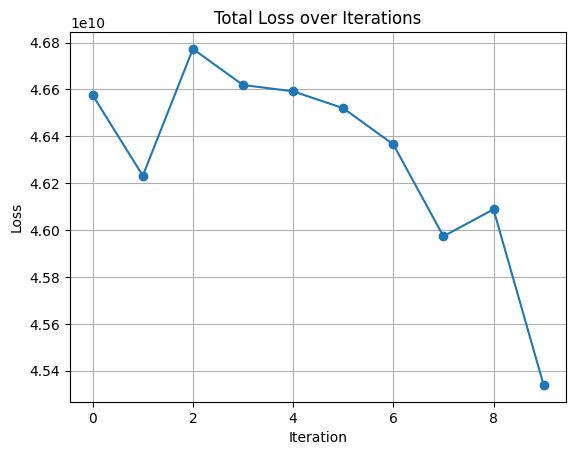

In [72]:
import matplotlib.pyplot as plt

losses = [h['TotalLoss'] for h in history]
plt.plot(losses, marker='o')
plt.title('Total Loss over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid()
plt.show()
